# ⚡ Smart Electricity Consumption Prediction & Energy Optimization System
### TEYZIX CORE Internship — Task ML-3

**Domain:** Machine Learning | **Difficulty:** Advanced (Industry-Based)

This notebook walks through the complete ML lifecycle:
1. Original Dataset Creation
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training (4 algorithms)
6. Model Evaluation
7. Prediction Demo
8. Energy Optimization Recommendations

> **Note:** No public dataset (Kaggle/UCI/GitHub) is used. The dataset is
> 100% originally generated — see `data/generate_dataset.py`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_style("whitegrid")
PINK = "#F8B8D0"
DARK_PINK = "#E75480"
%matplotlib inline


## 1️⃣ Original Dataset Creation

Dataset generated via `data/generate_dataset.py` using realistic domain-driven synthetic simulation (appliance wattage rules + seasonal/temperature effects + noise). Loading it here:

In [2]:
df = pd.read_csv("../data/electricity_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (1212, 20)


,House_Type,Family_Members,Number_of_Rooms,AC_Units,AC_Usage_Hours,Fan_Usage_Hours,Refrigerator_Usage_Hours,Washing_Machine_Usage_Hours,Water_Motor_Usage_Hours,Lighting_Hours,TV_Usage_Hours,Iron_Usage_Hours,Kitchen_Appliance_Hours,Daily_Appliance_Count,Outdoor_Temperature_C,Day_of_Week,Is_Weekend,Season,Is_Holiday,Daily_Electricity_Consumption_kWh
0,Portion/Rented Unit,3,2,0,0.00,9.46,24,0.32,1.58,8.05,4.27,0.15,2.51,6,9.3,Thursday,0,Winter,0,9.15
1,Portion/Rented Unit,6,6,1,9.36,9.62,24,0.60,1.56,10.02,1.56,0.21,1.94,13,28.3,Saturday,1,Monsoon,0,18.22
2,Independent House,7,2,1,0.68,8.53,24,0.91,0.67,6.41,4.29,0.02,3.30,7,24.0,Thursday,0,Monsoon,1,13.69
3,Independent House,6,2,0,0.00,13.44,24,0.72,1.36,6.75,3.51,0.21,2.36,13,26.8,Sunday,1,Spring,0,9.66
4,Portion/Rented Unit,9,4,2,9.63,17.07,24,1.14,1.14,9.00,8.87,0.27,1.54,13,NaN,Sunday,1,Monsoon,0,31.20


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   House_Type                         1212 non-null   str    
 1   Family_Members                     1212 non-null   int64  
 2   Number_of_Rooms                    1212 non-null   int64  
 3   AC_Units                           1212 non-null   int64  
 4   AC_Usage_Hours                     1188 non-null   float64
 5   Fan_Usage_Hours                    1212 non-null   float64
 6   Refrigerator_Usage_Hours           1212 non-null   int64  
 7   Washing_Machine_Usage_Hours        1212 non-null   float64
 8   Water_Motor_Usage_Hours            1188 non-null   float64
 9   Lighting_Hours                     1212 non-null   float64
 10  TV_Usage_Hours                     1212 non-null   float64
 11  Iron_Usage_Hours                   1212 non-null   float64
 12  Kit

## 2️⃣ Data Preprocessing

Handling missing values, duplicates, outliers, and encoding categorical features.

In [4]:
print("Missing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 AC_Usage_Hours             24
Water_Motor_Usage_Hours    24
Outdoor_Temperature_C      24
dtype: int64

Duplicate rows: 12


In [5]:
# Handle missing values (median imputation)
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Outlier handling (IQR capping on target)
target = "Daily_Electricity_Consumption_kWh"
q1, q3 = df[target].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
df[target] = df[target].clip(lower, upper)

print("Cleaned shape:", df.shape)


Cleaned shape: (1200, 20)


In [6]:
# Encode categoricals
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    encoders[col] = le

df.head()


/tmp/ipykernel_587/1506016359.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


,House_Type,Family_Members,Number_of_Rooms,AC_Units,AC_Usage_Hours,Fan_Usage_Hours,Refrigerator_Usage_Hours,Washing_Machine_Usage_Hours,Water_Motor_Usage_Hours,Lighting_Hours,...,Daily_Appliance_Count,Outdoor_Temperature_C,Day_of_Week,Is_Weekend,Season,Is_Holiday,Daily_Electricity_Consumption_kWh,House_Type_enc,Day_of_Week_enc,Season_enc
0,Portion/Rented Unit,3,2,0,0.00,9.46,24,0.32,1.58,8.05,...,6,9.3,Thursday,0,Winter,0,9.15,3,4,3
1,Portion/Rented Unit,6,6,1,9.36,9.62,24,0.60,1.56,10.02,...,13,28.3,Saturday,1,Monsoon,0,18.22,3,2,0
2,Independent House,7,2,1,0.68,8.53,24,0.91,0.67,6.41,...,7,24.0,Thursday,0,Monsoon,1,13.69,2,4,0
3,Independent House,6,2,0,0.00,13.44,24,0.72,1.36,6.75,...,13,26.8,Sunday,1,Spring,0,9.66,2,3,1
4,Portion/Rented Unit,9,4,2,9.63,17.07,24,1.14,1.14,9.00,...,13,28.7,Sunday,1,Monsoon,0,31.20,3,3,0


## 3️⃣ Exploratory Data Analysis (EDA)

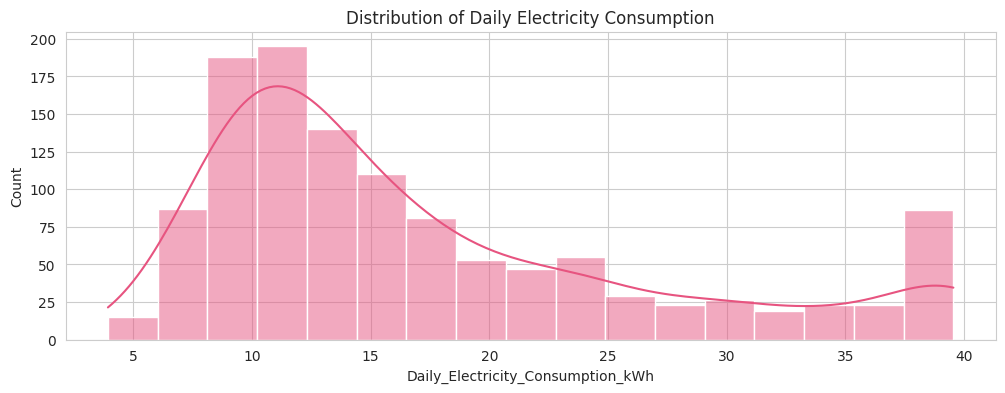

In [7]:
plt.figure(figsize=(12,4))
sns.histplot(df[target], kde=True, color=DARK_PINK)
plt.title("Distribution of Daily Electricity Consumption")
plt.show()


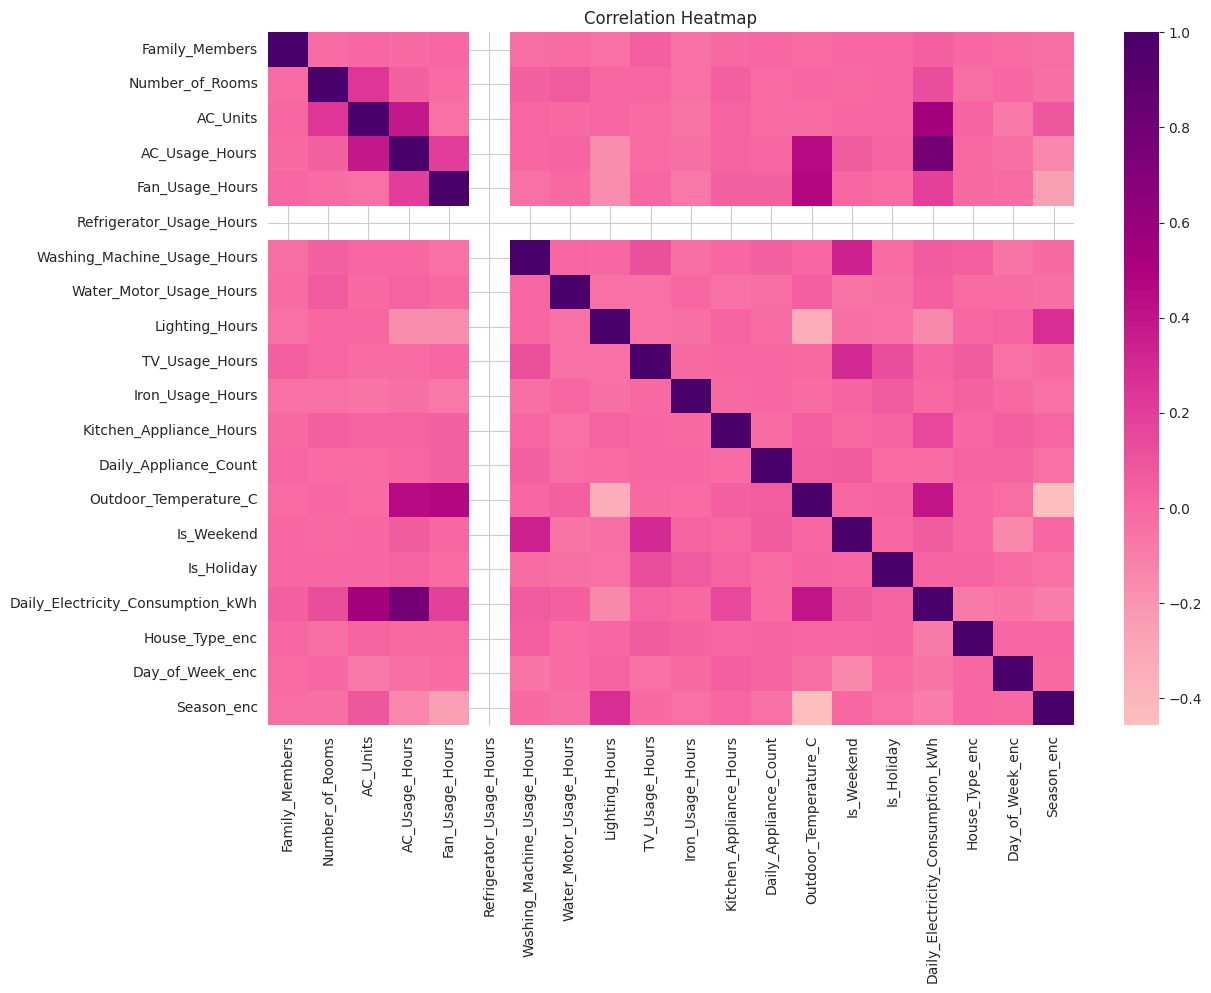

In [8]:
plt.figure(figsize=(13,9))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="RdPu", center=0)
plt.title("Correlation Heatmap")
plt.show()


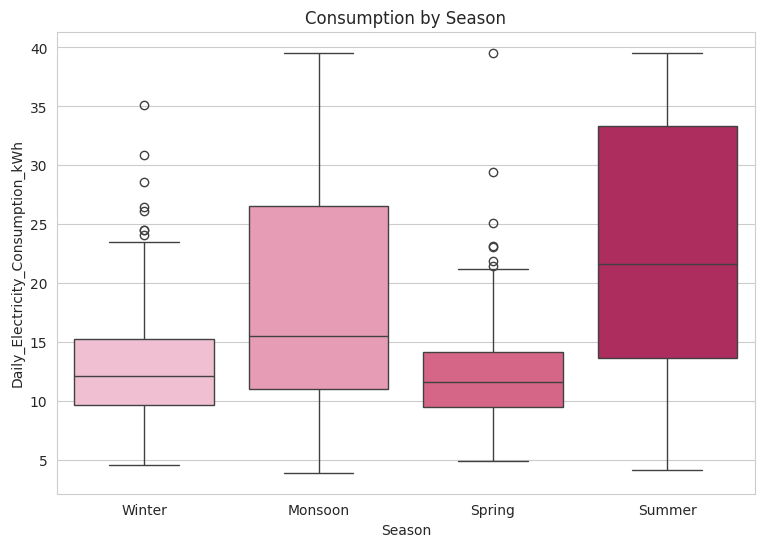

In [9]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Season", y=target, hue="Season", palette=[PINK, "#F48FB1", DARK_PINK, "#C2185B"], legend=False)
plt.title("Consumption by Season")
plt.show()


In [10]:
corr_target = df.select_dtypes(include=np.number).corr()[target].drop(target).sort_values(ascending=False)
print("Top correlated features with target:\n", corr_target.head(5))


Top correlated features with target:
 AC_Usage_Hours             0.785984
AC_Units                   0.544084
Outdoor_Temperature_C      0.393325
Fan_Usage_Hours            0.194398
Kitchen_Appliance_Hours    0.152384
Name: Daily_Electricity_Consumption_kWh, dtype: float64


**Business Insight:** AC usage hours and outdoor temperature are the strongest
drivers of electricity consumption. Summer months and Bungalow-type houses
show the highest average consumption — suggesting targeted energy-saving
campaigns for cooling appliances during peak summer.

## 4️⃣ Feature Engineering

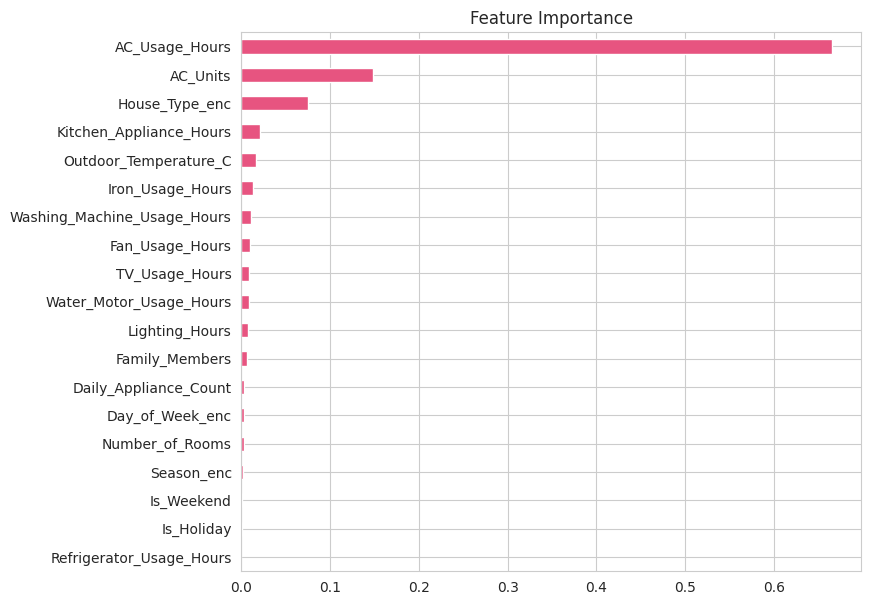

In [11]:
feature_cols = [
    "Family_Members", "Number_of_Rooms", "AC_Units", "AC_Usage_Hours",
    "Fan_Usage_Hours", "Refrigerator_Usage_Hours", "Washing_Machine_Usage_Hours",
    "Water_Motor_Usage_Hours", "Lighting_Hours", "TV_Usage_Hours",
    "Iron_Usage_Hours", "Kitchen_Appliance_Hours", "Daily_Appliance_Count",
    "Outdoor_Temperature_C", "Is_Weekend", "Is_Holiday",
    "House_Type_enc", "Day_of_Week_enc", "Season_enc"
]
X = df[feature_cols]
y = df[target]

# Feature importance via quick Random Forest
rf_fi = RandomForestRegressor(n_estimators=200, random_state=42).fit(X, y)
importance = pd.Series(rf_fi.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.plot(kind="barh", figsize=(8,7), color=DARK_PINK)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()


## 5️⃣ Model Training — 4 Algorithms Compared

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {}

# Linear Regression
lr = LinearRegression().fit(X_train_scaled, y_train)
models["Linear Regression"] = (lr, X_test_scaled)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=2, random_state=42, n_jobs=-1).fit(X_train, y_train)
models["Random Forest"] = (rf, X_test)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=4, random_state=42).fit(X_train, y_train)
models["Gradient Boosting"] = (gb, X_test)

# XGBoost with light hyperparameter tuning
grid = GridSearchCV(XGBRegressor(random_state=42, objective="reg:squarederror"),
                     {"n_estimators":[150,300], "max_depth":[3,5], "learning_rate":[0.05,0.1]},
                     cv=3, scoring="r2", n_jobs=-1).fit(X_train, y_train)
models["XGBoost (tuned)"] = (grid.best_estimator_, X_test)
print("Best XGB params:", grid.best_params_)


Best XGB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}


## 6️⃣ Model Evaluation

In [13]:
results = {}
preds = {}
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    preds[name] = y_pred
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T.round(3)
results_df.sort_values("R2", ascending=False)


,MAE,MSE,RMSE,R2
Gradient Boosting,1.905,8.295,2.880,0.916
XGBoost (tuned),1.880,8.402,2.899,0.915
Random Forest,2.055,9.287,3.047,0.906
Linear Regression,3.916,24.472,4.947,0.751


Best Model: Gradient Boosting


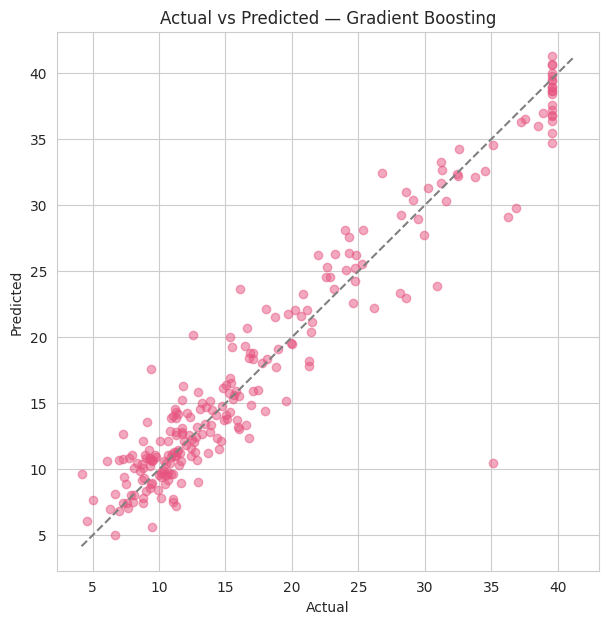

In [14]:
best_name = results_df["R2"].idxmax()
print("Best Model:", best_name)

plt.figure(figsize=(7,7))
plt.scatter(y_test, preds[best_name], alpha=0.5, color=DARK_PINK)
lims = [min(y_test.min(), preds[best_name].min()), max(y_test.max(), preds[best_name].max())]
plt.plot(lims, lims, "--", color="gray")
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted — {best_name}")
plt.show()


## 7️⃣ Prediction Demo — Sample Household

In [15]:
sample = X_test.iloc[[0]]
best_model, _ = models[best_name]
X_input = scaler.transform(sample) if best_name == "Linear Regression" else sample
pred = best_model.predict(X_input)[0]
print(f"Predicted daily consumption: {pred:.2f} kWh")
print(f"Estimated monthly usage: {pred*30:.1f} kWh")
print(f"Actual value was: {y_test.iloc[0]:.2f} kWh")


Predicted daily consumption: 21.18 kWh
Estimated monthly usage: 635.4 kWh
Actual value was: 21.50 kWh


## 8️⃣ Energy Optimization Recommendations (Logic Demo)

The full interactive version of this logic is available in `app/streamlit_app.py`.
Example rule-based recommendation logic:

- AC usage > 6 hrs/day → suggest raising thermostat by 2°C (10–15% savings)
- Washing machine used on weekdays → suggest shifting to off-peak hours
- Lighting hours > 8 → suggest LED bulb upgrade
- Efficiency score < 50 → flag high standby/base load for review

## ✅ Conclusion

The **Gradient Boosting Regressor** achieved the best performance (R² ≈ 0.916),
significantly outperforming Linear Regression, confirming that electricity
consumption has non-linear relationships with appliance usage patterns. The
full production system (Streamlit app, PDF/Excel reports, SHAP explainability)
is available in the accompanying project files.
